# Multimodal latent embedding with MuVI for MCL gene and protein expression data

First import the relevant packages

In [3]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import muon as mu



import pyro

from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
import muvi

In [5]:
%matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

Using matplotlib backend: <object object at 0x7f20c8c493d0>


In [6]:
# plotting settings
sns.set()
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("notebook")

Check whether the gpu is available and free

In [7]:
try:
    gpu_idx = muvi.get_free_gpu_idx()
    print("Using GPU #%s" % gpu_idx)
    os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_idx)
except Exception as e:
    print(e)

Using GPU #0


The data was preprocessed in R and extracted as a .h5mu MuData object. Load the data.

In [8]:
mdata = mu.read("mclmu_upd.h5mu")
mdata

/home/jenssle/miniconda3/envs/muvi/lib/python3.8/site-packages/mudata/_core/mudata.py:458: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


MuData object with n_obs × n_vars = 261 × 21538
  obs:	'bulk_rnaseq_koln', 'proteomics_frankfurt', 'Prot_id', 'cohort'
  2 modalities
    RNAseq:	261 x 14404
    gProt:	261 x 7134

Perform a simple preprocessing by centering the data I have not filtered the RNAseq for highly variable genes but filtered the proteome data for missing value cut-off of 80%. Finally, update the MuData object.

In [9]:
missing_threshold = 0.8

for view_name, adata in mdata.mod.items():
    
    nan_values = np.isnan(adata.X)
    missing_features = nan_values.mean(axis=0) > missing_threshold
    nan_vars = np.isnan(np.nanvar(adata.X, axis=0))
    bad_features = nan_vars | missing_features

    print(
        f"View {view_name} has {bad_features.sum()} ({100*bad_features.mean():.1f}%) partially missing features (>{missing_threshold}), removing..."
    )
    
    print("Centering features")
    adata.X -= np.nanmean(adata.X, axis=0)
    global_std = np.nanstd(adata.X)
    print(f"Global std of {view_name} before: {global_std}")
    adata.X /= global_std
    print(f"Global std of {view_name}: {np.nanstd(adata.X)}")

mdata.update()

View RNAseq has 0 (0.0%) partially missing features (>0.8), removing...
Centering features
Global std of RNAseq before: 0.8136508144629128
Global std of RNAseq: 0.9999999999999998
View gProt has 908 (12.7%) partially missing features (>0.8), removing...
Centering features
Global std of gProt before: 0.2728763655814169
Global std of gProt: 0.9999999999999997


/tmp/ipykernel_89728/4131447216.py:15: RuntimeWarning: invalid value encountered in subtract
  adata.X -= np.nanmean(adata.X, axis=0)
/tmp/ipykernel_89728/4131447216.py:7: RuntimeWarning: Degrees of freedom <= 0 for slice.
  nan_vars = np.isnan(np.nanvar(adata.X, axis=0))
/tmp/ipykernel_89728/4131447216.py:15: RuntimeWarning: Mean of empty slice
  adata.X -= np.nanmean(adata.X, axis=0)
/home/jenssle/miniconda3/envs/muvi/lib/python3.8/site-packages/mudata/_core/mudata.py:458: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


Now, load the pathway object stored in the msigdbr folder

In [25]:
measured_pathways, pathway_df = muvi.fs.load_pathways(
    ["nih"],
    mdata.var_names,
    fraction_available=0.1,
    min_gene_count=15,
    max_gene_count = 800,
    msigdb_version="7.5.1",
)

measured_pathways = measured_pathways.merge_duplicates()

measured_pathways

2023-03-07 11:33:35,893 - muvi.tools.feature_sets - INFO - Loading collection `nih` with at least 10.0%% of genes available and at least {min_gene_count[i]} genes.
2023-03-07 11:33:35,928 - muvi.tools.feature_sets - INFO - Loaded 315 pathways from collection `nih` with median size of 61.0 genes
2023-03-07 11:33:35,931 - muvi.tools.feature_sets - INFO - Loaded in total 315 pathways with median size of 61.0 genes


<GeneSets with 315 gene sets>

Visualize the distribution of each gene set size grouped by each gene set collection

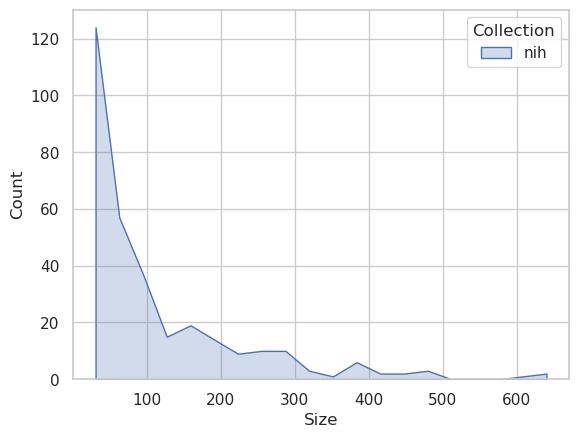

In [26]:
sns.histplot(
    pd.concat(pathway_df).reset_index(), x="Size", hue="Collection", element="poly"
)
plt.show()

Generally, the gene set collections inform different views differently. That is, some gene sets may inform a single view only, while other gene sets inform both views jointly. Therefore, we store the prior information into the corresponding AnnData inside the MuData object.

Unfortunately, the SignatureDB is derived from transcriptomic studies. However, since we saw in other projects also relevant structure in the proteomic data regarding the SignatureDB feature sets, I will also inform the proteome view

Finally, we convert the prior information into a numerical representation such as a binary matrix.

In [27]:
adata = mdata["RNAseq"]
gene_set_mask, gene_sets = measured_pathways.to_mask(adata.var_names.tolist())

adata.uns["gene_set_name"] = [gsn.name for gsn in gene_sets]

adata.varm["gene_set_mask"] = pd.DataFrame(
    gene_set_mask.astype("bool").T,
    index=adata.var_names,
    columns=adata.uns["gene_set_name"],
)

mdata.uns["gene_set_name"] = adata.uns["gene_set_name"]

In [28]:
adata = mdata["gProt"]
gene_set_mask, gene_sets = measured_pathways.to_mask(adata.var_names.tolist())

adata.uns["gene_set_name"] = [gsn.name for gsn in gene_sets]

adata.varm["gene_set_mask"] = pd.DataFrame(
    gene_set_mask.astype("bool").T,
    index=adata.var_names,
    columns=adata.uns["gene_set_name"],
)

mdata.uns["gene_set_name"] = adata.uns["gene_set_name"]

Now, generate a MuVI model directly from the MuData object

In [29]:
model = muvi.tl.from_mdata(
    mdata, prior_mask_key="gene_set_mask", view_names=["RNAseq", "gProt"], use_gpu=True
)

2023-03-07 11:34:24,538 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,539 - muvi.core.models - INFO - Storing the index of the view `RNAseq` as sample names.
2023-03-07 11:34:24,540 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,541 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,542 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,550 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,551 - muvi.core.models - INFO - Storing the index of the mask `RNAseq` as factor names.
2023-03-07 11:34:24,553 - muvi.core.models - INFO - pd.DataFrame detected.
2023-03-07 11:34:24,574 - muvi.core.models - INFO - Likelihoods set to `{'RNAseq': 'normal', 'gProt': 'normal'}`.
2023-03-07 11:34:24,575 - muvi.core.models - INFO - GPU available, running all computations on the GPU.


Now, train the model 

In [37]:
n_epochs = 8000
loss_history, _ = model.fit(
    batch_size=1000,
    n_epochs=n_epochs,
    n_particles=1,
    learning_rate=0.005,
    optimizer="clipped",
    verbose=1,
    seed=0,
)

2023-03-07 11:42:49,072 - muvi.core.models - INFO - Preparing model and guide...
2023-03-07 11:42:49,074 - muvi.core.models - INFO - Preparing optimizer...
2023-03-07 11:42:49,075 - muvi.core.models - INFO - Decaying learning rate over 8000 iterations.
2023-03-07 11:42:49,077 - muvi.core.models - INFO - Preparing SVI...
2023-03-07 11:42:49,078 - muvi.core.models - INFO - Preparing training data...
2023-03-07 11:42:49,117 - muvi.core.models - INFO - Using complete dataset.
2023-03-07 11:42:49,128 - muvi.core.models - INFO - Setting training seed to `0`.
2023-03-07 11:42:49,129 - muvi.core.models - INFO - Cleaning parameter store.
2023-03-07 11:42:49,130 - muvi.core.models - INFO - Starting training...



  0%|                                                  | 0/8000 [00:00<?, ?it/s]

2023-03-07 11:42:49,172 - root - INFO - Guessed max_plate_nesting = 2


100%|█████████████████████████| 8000/8000 [10:07<00:00, 13.16it/s, ELBO=2.81e+4]


Check the overall variance explained

In [38]:
r2_view, r2_factor, r2_cov = muvi.tl.variance_explained(model)
r2_view

2023-03-07 11:53:06,001 - muvi.tools.utils - WARNING - Cache has not yet been setup, initialising model cache.


{'RNAseq': 0.5377826988697052, 'gProt': 0.40181785821914673}

Visualize the variance explained per factor

<Axes: >

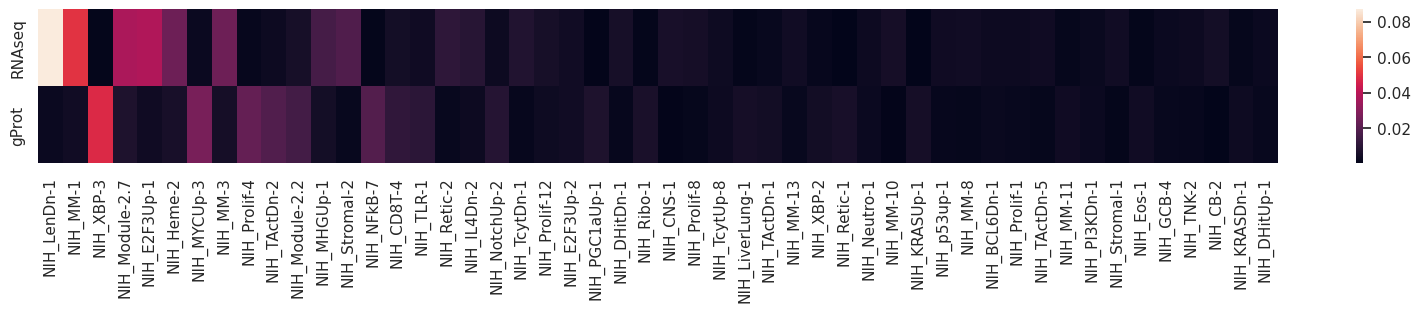

In [39]:
# to speed up the process, use a random subsample to approximate the variance explained
muvi.tl.variance_explained(model, subsample=1000)
muvi.pl.variance_explained(model)

Next, we perform a statistical test (PCGSE) to determine how well the inferred factors match the prior information representing each pathway. Here, we apply a correlation adjusted one-sided t-test, and correcting for multiple testing.

Unless we provide other feature sets, e.g. Gene Ontology, muvi automatically compares each inferred factor against its corresponding prior gene set annotation. Since we only inform the RNA view, we may not apply this function on the uninformed views such as the ATAC view in our case.

In [40]:
for sign in ["neg", "pos"]:
    muvi.tl.test(model, view_idx="RNAseq", sign=sign)

2023-03-07 11:54:18,500 - muvi.tools.utils - WARNING - No feature sets provided, extracting feature sets from prior mask.


100%|█████████████████████████████████████████| 313/313 [00:20<00:00, 15.12it/s]


2023-03-07 11:54:40,450 - muvi.tools.utils - WARNING - No feature sets provided, extracting feature sets from prior mask.


100%|█████████████████████████████████████████| 313/313 [00:20<00:00, 15.11it/s]


In [41]:
for sign in ["neg", "pos"]:
    muvi.tl.test(model, view_idx="gProt", sign=sign)

2023-03-07 11:57:28,332 - muvi.tools.utils - WARNING - No feature sets provided, extracting feature sets from prior mask.


100%|█████████████████████████████████████████| 285/285 [00:12<00:00, 22.37it/s]


2023-03-07 11:57:42,273 - muvi.tools.utils - WARNING - No feature sets provided, extracting feature sets from prior mask.


100%|█████████████████████████████████████████| 285/285 [00:12<00:00, 22.81it/s]


Now we may plot an overview of the most relevant factors by combining the variance explained and the results of the statistical test. Since we applied a one-sided hypothesis test, each significant factor is marked by a (+) or (-) indicating the significance direction. A factor may also be significant in both directions. However, we report the more significant direction based on the lower p-value.

For the uninformed views, i.e. ATAC, we omit any information regarding the statistical testing, and only sort the factors by their corresponding variance explained.

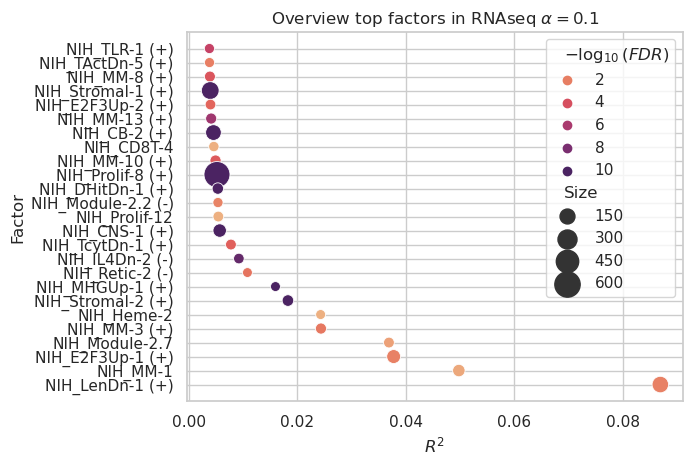

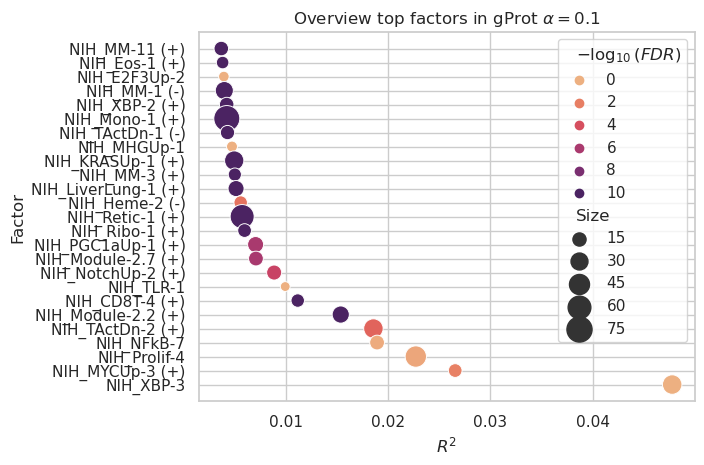

In [42]:
for vn in model.view_names:
    muvi.pl.factors_overview(
        model,
        vn,
        one_sided=True,
        alpha=0.1,
        sig_only=False,
        adjusted=True,
        top=25,
        show=True,
    )

Quickly extract the total variance explained

Now, safe the model as an dhf5 file 

In [52]:
muvi.ext.save_as_hdf5(model, '/home/jenssle/MuVI/muvimcl.hdf5', save_metadata=True)

2023-03-07 13:03:45,052 - muvi.tools.external - INFO - Setting default group name to `group_0` for single group data.
2023-03-07 13:03:45,055 - muvi.tools.external - INFO - Computing variance explained.
